# Task 4: Predicting Insurance Claim Amounts

This task aims to predict medical insurance charges using regression techniques.

In [1]:
import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Dataset Overview

This dataset contains information about individuals such as age, BMI, smoking status, and their medical insurance charges.

In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Data Understanding

The dataset includes both numerical and categorical variables.
Charges is the target variable.

In [3]:
df = pd.get_dummies(df, drop_first=True)

## Data Encoding

Categorical variables were converted into numerical format.

In [4]:
X = df.drop('charges', axis=1)
y = df['charges']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Data Splitting

The dataset is divided into training and testing sets.

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Training

Linear Regression model is used to predict insurance charges.

In [7]:
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4073.1208593763668
RMSE: 5646.963961316067


## Model Evaluation

MAE and RMSE are used to measure prediction error.
Lower values indicate better performance.

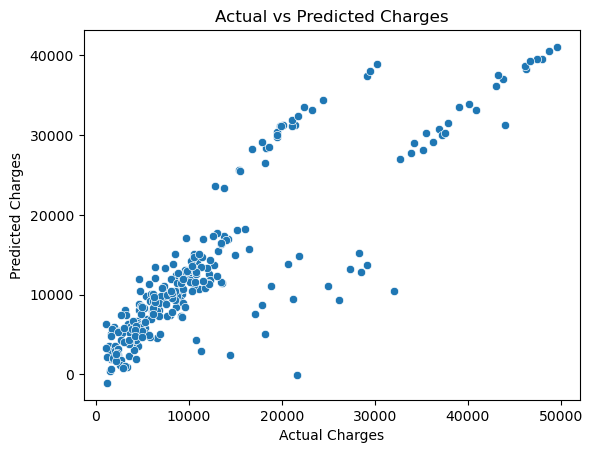

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

## Visualization

This scatter plot compares actual insurance charges with predicted values.
If the model is good, points should lie close to a straight line.

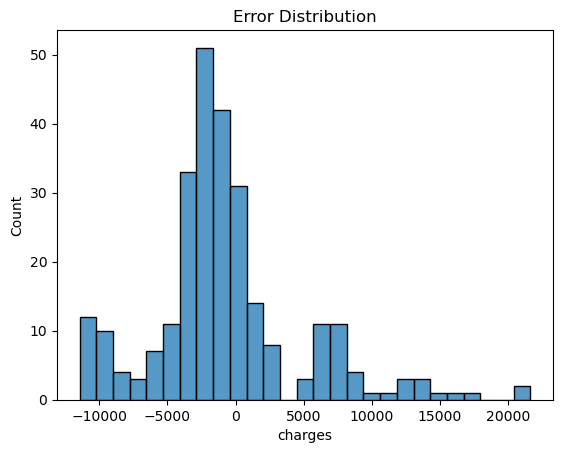

In [11]:
sns.histplot(y_test - y_pred)
plt.title("Error Distribution")
plt.show()

This graph shows the distribution of prediction errors.

## Conclusion

- Data was preprocessed and categorical values were encoded.
- Linear Regression model was trained.
- MAE and RMSE were used to evaluate performance.
- The model predicts insurance charges based on input features.